<a href="https://colab.research.google.com/github/maybraniswe/Retail-Store-Sales-Analysis-and-Prediction/blob/main/PDSE%20Project_Retail%20Store%20Sales%20Analysis%20and%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retail Store Sales Analysis and Prediction

In [36]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler

##Data Loading

In [26]:
# read the data from csv file
df = pd.read_csv('https://raw.githubusercontent.com/maybraniswe/Retail-Store-Sales-Analysis-and-Prediction/refs/heads/main/retail_store_sales.csv?token=GHSAT0AAAAAAD2KAZTUGMAGGEYJ3HK75XTY2PGB4FQ')
# Dataset size check (rows, columns)
print (df.shape)

(12575, 11)


In [16]:
# View data the first 5 rows
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [27]:
# View data the first 5 rows
df.tail()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


In [29]:
# Check summary statistics
df.describe().round(2)

,Price Per Unit,Quantity,Total Spent
count,11966.00,11971.00,11971.00
mean,23.37,5.54,129.65
std,10.74,2.86,94.75
min,5.00,1.00,5.00
25%,14.00,3.00,51.00
50%,23.00,6.00,108.50
75%,33.50,8.00,192.00
max,41.00,10.00,410.00


In [19]:
# Check structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [20]:
# Checking for missing values
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


In [31]:
df.nunique()

,0
Transaction ID,12575
Customer ID,25
Category,8
Item,200
Price Per Unit,25
Quantity,10
Total Spent,227
Payment Method,3
Location,2
Transaction Date,1114


In [33]:
df['Item'].nunique()

200

In [32]:
# Best selling Item analysis
df['Item'].value_counts()

,count
Item,
Item_2_BEV,126
Item_25_FUR,113
Item_11_FUR,110
Item_16_MILK,109
Item_1_MILK,109
...,...
Item_5_BEV,7
Item_13_BEV,7
Item_13_FUR,7


In [35]:
df[['Item', 'Price Per Unit']].drop_duplicates()

,Item,Price Per Unit
0,Item_10_PAT,18.5
1,Item_17_MILK,29.0
2,Item_12_BUT,21.5
3,Item_16_BEV,27.5
4,Item_6_FOOD,12.5
...,...,...
2031,Item_19_FOOD,32.0
2044,Item_14_EHE,24.5
2590,Item_3_EHE,8.0
2757,NaN,18.5


## Missing Values

In [21]:
# Fill missing numeric values using median (for outliers)
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

# Recalculate Total Spent
df['Total Spent'] = df['Price Per Unit'] * df['Quantity']

# Fill Discount Applied with 0 (assume no discount)
df['Discount Applied'] = df['Discount Applied'].fillna(0)

# Fill Item using group based method
df['Item'] = df.groupby('Price Per Unit')['Item'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'unknown')
)
print (df.isnull().sum())


Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64


##Converting Data Types

In [22]:
# Convert numeric columns
num_cols = ['Price Per Unit', 'Quantity', 'Total Spent', 'Discount Applied']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert date column
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

# Convert categorical columns
cat_cols = ['Transaction ID', 'Customer ID', 'Category', 'Item', 'Payment Method', 'Location']
for col in cat_cols:
    df[col] = df[col].astype('category')

print(df.dtypes)

Transaction ID            category
Customer ID               category
Category                  category
Item                      category
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method            category
Location                  category
Transaction Date    datetime64[ns]
Discount Applied             int64
dtype: object


##Standardizing Inconsistent Data

In [23]:
# Clean text data (remove spaces, lowercase)
df['Item'] = df['Item'].str.strip().str.lower()
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,item_10_pat,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,1
1,TXN_3731986,CUST_22,Milk Products,item_17_milk,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,1
2,TXN_9303719,CUST_02,Butchers,item_12_but,21.5,2.0,43.0,Credit Card,Online,2022-10-05,0
3,TXN_9458126,CUST_06,Beverages,item_16_bev,27.5,9.0,247.5,Credit Card,Online,2022-05-07,0
4,TXN_4575373,CUST_05,Food,item_6_food,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,0


##Handling Duplicates

In [24]:
# Remove duplicate rows
print("Duplicate rows before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after:", df.duplicated().sum())

Duplicate rows before: 0
Duplicate rows after: 0


##Univariate Analysis

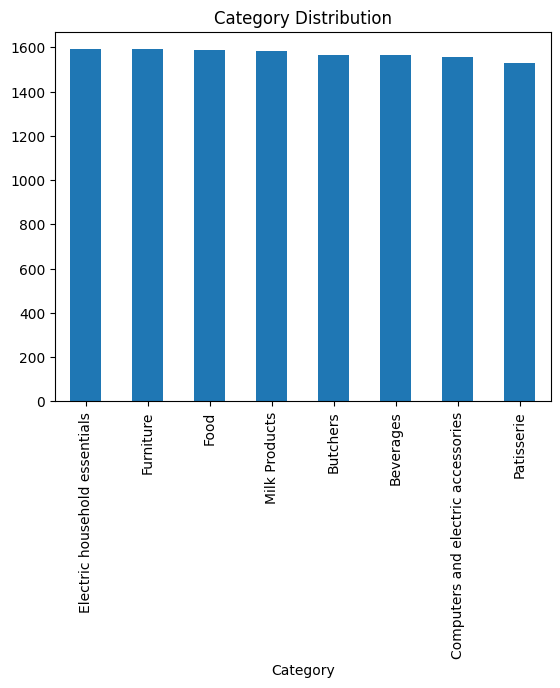

In [37]:
# Category (Bar chart)
df['Category'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.show()

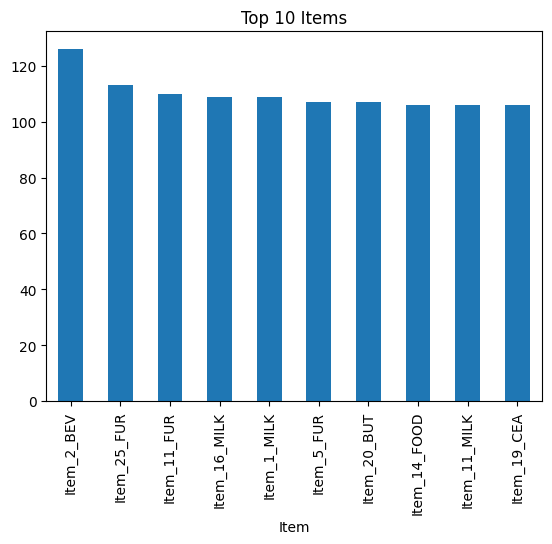

In [38]:
# Item (Top 10 items)
df['Item'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Items")
plt.show()

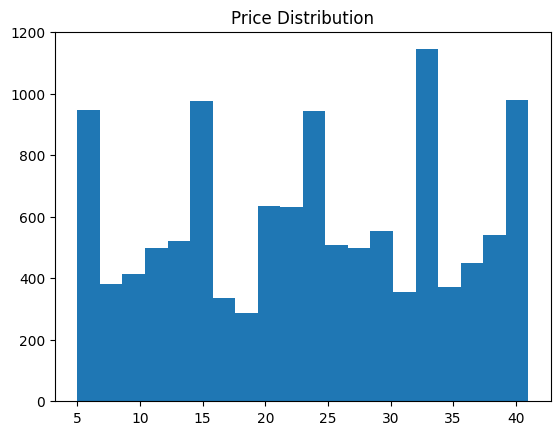

In [39]:
# Price Per Unit (Histogram)
plt.hist(df['Price Per Unit'], bins=20)
plt.title("Price Distribution")
plt.show()

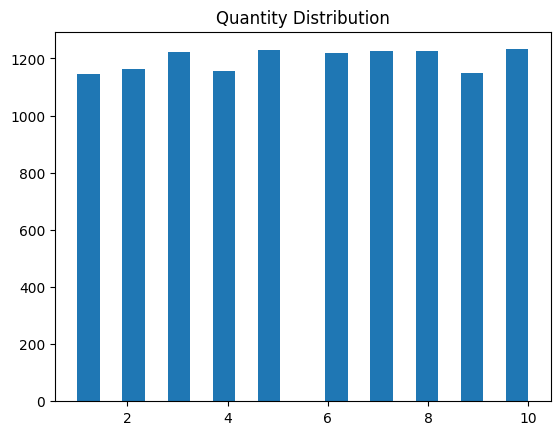

In [40]:
# Quantity (Histogram)
plt.hist(df['Quantity'], bins=20)
plt.title("Quantity Distribution")
plt.show()

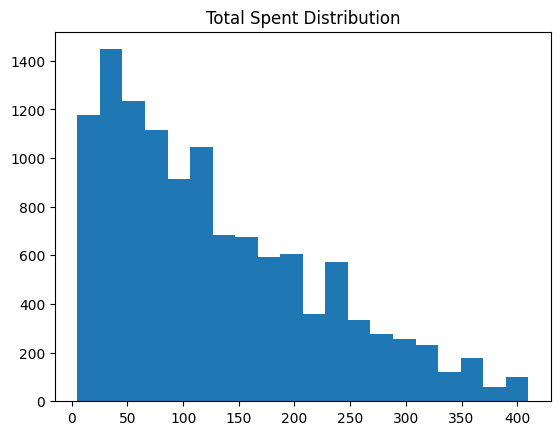

In [41]:
# Total Spent (Histogram)
plt.hist(df['Total Spent'], bins=20)
plt.title("Total Spent Distribution")
plt.show()

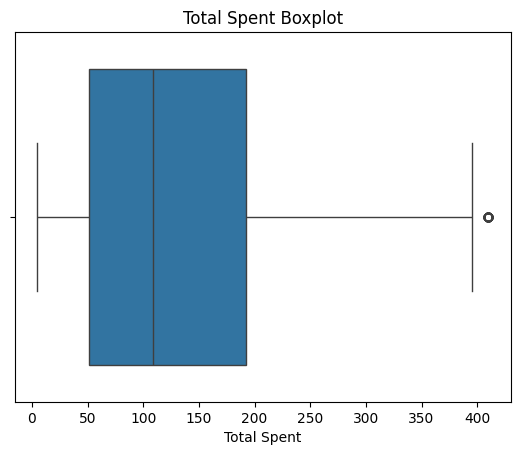

In [43]:
# Total Spent (Boxplot)
sns.boxplot(x=df['Total Spent'])
plt.title("Total Spent Boxplot")
plt.show()

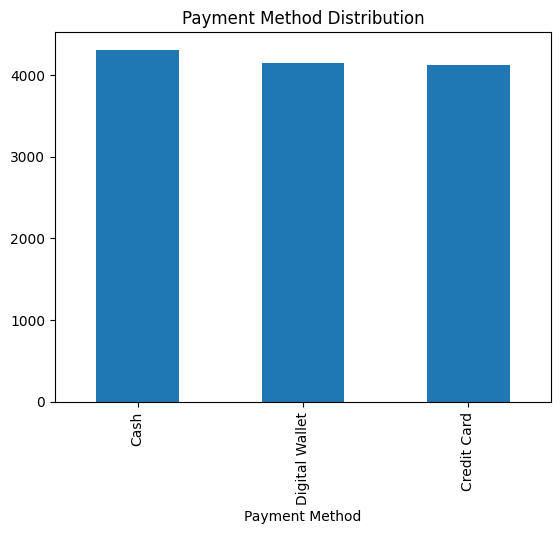

In [44]:
# Payment Method (Bar chart)
df['Payment Method'].value_counts().plot(kind='bar')
plt.title("Payment Method Distribution")
plt.show()

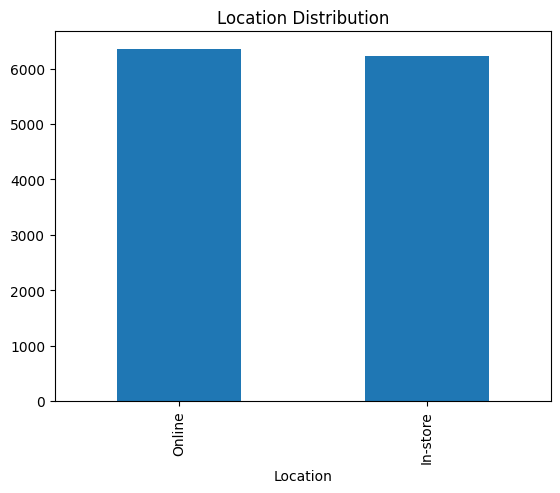

In [45]:
# Location (Bar chart)
df['Location'].value_counts().plot(kind='bar')
plt.title("Location Distribution")
plt.show()

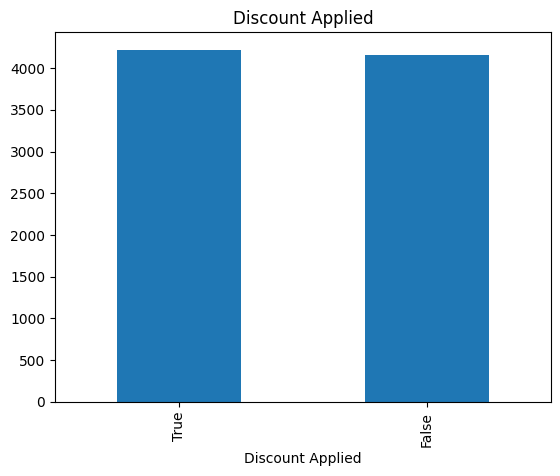

In [46]:
# Discount Applied (Bar chart)
df['Discount Applied'].value_counts().plot(kind='bar')
plt.title("Discount Applied")
plt.show()

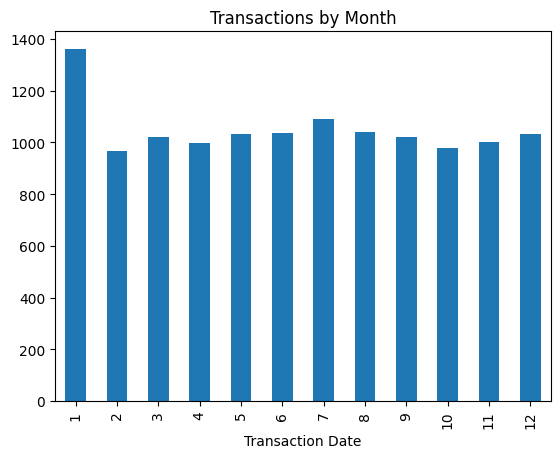

In [47]:
# Transaction Date (by month)

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

df['Transaction Date'].dt.month.value_counts().sort_index().plot(kind='bar')
plt.title("Transactions by Month")
plt.show()

##Multivariate Analysis

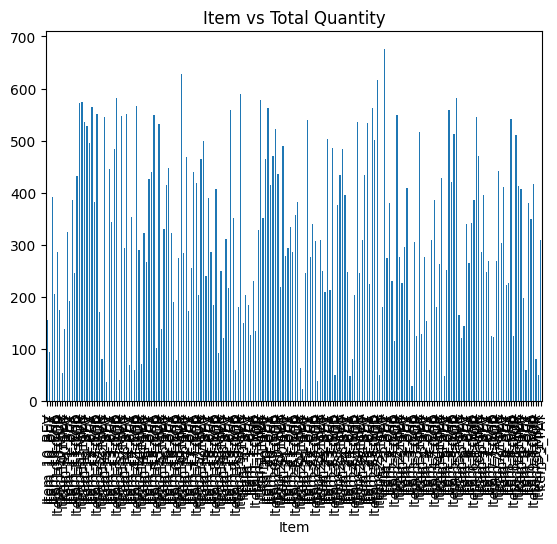

In [48]:
# Item vs Quantity
df.groupby('Item')['Quantity'].sum().plot(kind='bar')
plt.title("Item vs Total Quantity")
plt.show()

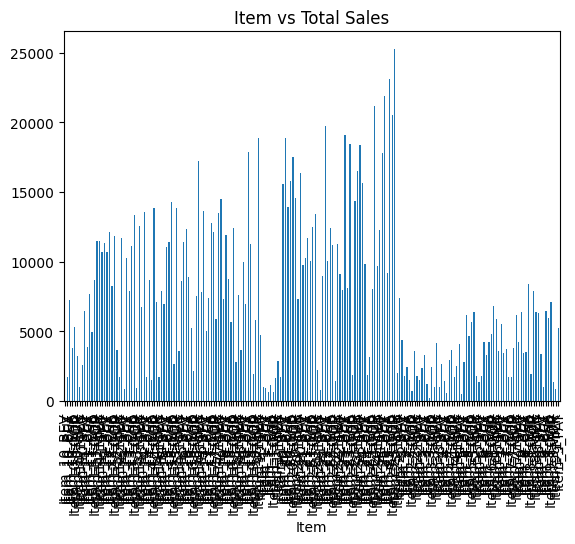

In [49]:
# Item vs Total Spent
df.groupby('Item')['Total Spent'].sum().plot(kind='bar')
plt.title("Item vs Total Sales")
plt.show()

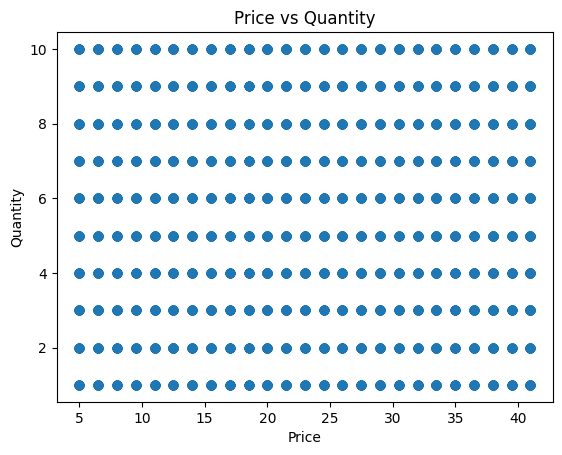

In [52]:
# Price vs Quantity (scatter)
plt.scatter(df['Price Per Unit'], df['Quantity'])
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.title("Price vs Quantity")
plt.show()

##Heatmap

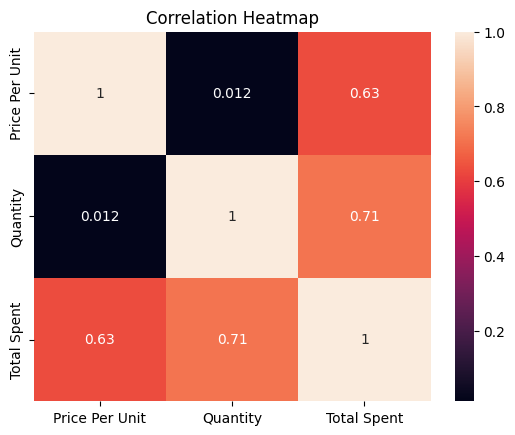

In [51]:
corr = df[['Price Per Unit', 'Quantity', 'Total Spent']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()